# Notebook 01 — Dataset Snort
---

## 1. Installation des dépendances

In [ ]:
%pip install pandas matplotlib seaborn

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp3


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## 3. Chargement du dataset

In [ ]:
df = pd.read_csv('../Datasets/snort_dataset.csv')
print(f'Dataset chargé : {len(df)} entrées')
df.head(10)

Dataset chargé : 50 entrées


,id,description,attack_type,protocol,severity,snort_rule
0,1,Détection d'un scan de ports SYN sur un serveu...,Port Scan,TCP,medium,"alert tcp any any -> $HOME_NET 80 (msg:""SYN Sc..."
1,2,Détection d'une attaque DoS par flood UDP,DoS,UDP,high,"alert udp any any -> $HOME_NET any (msg:""UDP F..."
2,3,Tentative de connexion SSH par brute force,Brute Force,TCP,high,"alert tcp any any -> $HOME_NET 22 (msg:""SSH Br..."
3,4,Injection SQL dans une requête HTTP GET,SQL Injection,TCP,critical,"alert tcp any any -> $HOME_NET 80 (msg:""SQL In..."
4,5,Scan de ports FTP pour recherche de services o...,Port Scan,TCP,low,"alert tcp any any -> $HOME_NET 21 (msg:""FTP Po..."
5,6,Attaque SYN Flood contre un serveur DNS,DoS,TCP,high,"alert tcp any any -> $HOME_NET 53 (msg:""SYN Fl..."
6,7,Tentative d'exploitation de buffer overflow vi...,Buffer Overflow,TCP,critical,"alert tcp any any -> $HOME_NET 21 (msg:""FTP Bu..."
7,8,Détection d'un reverse shell via connexion sor...,Reverse Shell,TCP,critical,"alert tcp $HOME_NET any -> any 4444 (msg:""Reve..."
8,9,Scan ICMP ping sweep sur le réseau interne,Reconnaissance,ICMP,low,"alert icmp any any -> $HOME_NET any (msg:""ICMP..."
9,10,Téléchargement d'un exécutable via HTTP non ch...,Malware,TCP,medium,"alert tcp any any -> $HOME_NET 80 (msg:""Téléch..."


## 4. Informations générales

In [ ]:
print('=== Infos générales ===')
print(df.info())
print('\n=== Valeurs manquantes ===')
print(df.isnull().sum())
print('\n=== Types uniques ===')
print('attack_type :', df['attack_type'].nunique(), 'types')
print('protocol    :', df['protocol'].nunique(), 'protocoles')
print('severity    :', df['severity'].nunique(), 'niveaux')

=== Infos générales ===
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           50 non-null     int64
 1   description  50 non-null     str  
 2   attack_type  50 non-null     str  
 3   protocol     50 non-null     str  
 4   severity     50 non-null     str  
 5   snort_rule   50 non-null     str  
dtypes: int64(1), str(5)
memory usage: 2.5 KB
None

=== Valeurs manquantes ===
id             0
description    0
attack_type    0
protocol       0
severity       0
snort_rule     0
dtype: int64

=== Types uniques ===
attack_type : 25 types
protocol    : 4 protocoles
severity    : 4 niveaux


## 5. Distribution des types d'attaques

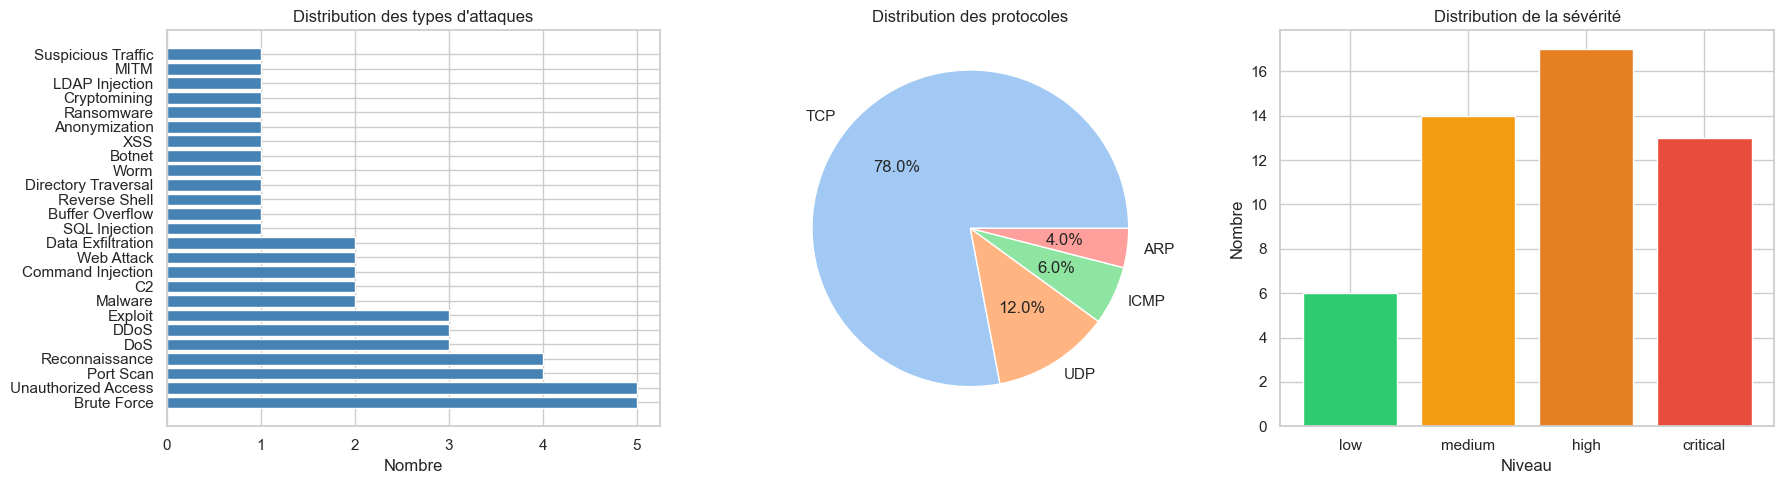

Graphiques sauvegardés dans Charts/01_distribution.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Attack Type ---
attack_counts = df['attack_type'].value_counts()
axes[0].barh(attack_counts.index, attack_counts.values, color='steelblue')
axes[0].set_title('Distribution des types d\'attaques')
axes[0].set_xlabel('Nombre')

# --- Protocol ---
protocol_counts = df['protocol'].value_counts()
axes[1].pie(protocol_counts.values, labels=protocol_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1].set_title('Distribution des protocoles')

# --- Severity ---
severity_order = ['low', 'medium', 'high', 'critical']
severity_counts = df['severity'].value_counts().reindex(severity_order)
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[2].bar(severity_counts.index, severity_counts.values, color=colors)
axes[2].set_title('Distribution de la sévérité')
axes[2].set_xlabel('Niveau')
axes[2].set_ylabel('Nombre')

plt.tight_layout()
os.makedirs('../Charts', exist_ok=True)
plt.savefig('../Charts/01_distribution.png', dpi=150)
plt.show()
print('Graphiques sauvegardés dans Charts/01_distribution.png')

## 6. Analyse de la longueur des descriptions

In [23]:
df['desc_length'] = df['description'].apply(lambda x: len(x.split()))
df['rule_length'] = df['snort_rule'].apply(lambda x: len(x))

print('=== Longueur des descriptions (mots) ===')
print(df['desc_length'].describe().round(2))

print('\n=== Longueur des règles Snort (caractères) ===')
print(df['rule_length'].describe().round(2))

=== Longueur des descriptions (mots) ===
count    50.00
mean      7.04
std       1.28
min       4.00
25%       6.00
50%       7.00
75%       8.00
max      10.00
Name: desc_length, dtype: float64

=== Longueur des règles Snort (caractères) ===
count     50.00
mean     135.84
std       24.25
min       84.00
25%      119.00
50%      140.50
75%      149.75
max      191.00
Name: rule_length, dtype: float64


## 7. Tableau croisé : Protocole × Sévérité

severity  critical  high  low  medium
protocol                             
ARP              1     0    1       0
ICMP             0     2    1       0
TCP             12    10    3      14
UDP              0     5    1       0


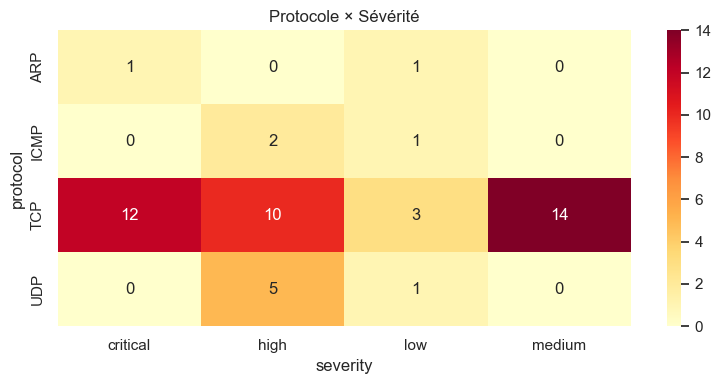

In [26]:
cross = pd.crosstab(df['protocol'], df['severity'])
print(cross)

plt.figure(figsize=(8, 4))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Protocole × Sévérité')
plt.tight_layout()
os.makedirs('../Charts', exist_ok=True)
plt.savefig('../Charts/01_heatmap_Pro_Sev.png', dpi=150)
plt.show()

## 8. Export du dataset nettoyé

In [28]:
# On supprime les colonnes temporaires avant export
df_clean = df.drop(columns=['desc_length', 'rule_length'])
os.makedirs('../Datasets', exist_ok=True)
df_clean.to_csv('../Datasets/snort_dataset_clean.csv', index=False)
df_clean.to_json('../Datasets/snort_dataset_clean.json', orient='records', force_ascii=False, indent=2)
print('Dataset exporté en CSV et JSON')
print(f'   → snort_dataset_clean.csv ({len(df_clean)} lignes)')
print(f'   → snort_dataset_clean.json ({len(df_clean)} entrées)')

Dataset exporté en CSV et JSON
   → snort_dataset_clean.csv (50 lignes)
   → snort_dataset_clean.json (50 entrées)


---
## ✅ Résumé
| Élément | Valeur |
|---|---|
| Nombre total d'entrées | 50 |
| Types d'attaques couverts | 16 |
| Protocoles | TCP, UDP, ICMP, ARP |
| Niveaux de sévérité | low, medium, high, critical |